# Animated TV Shows Around the World (1948–2023)
## Predicting Success with Machine Learning

**Dataset:** Wikipedia animated shows (3,604 titles) enriched with IMDb ratings  
**Goal:** Identify what makes a kids show successful using Random Forest and XGBoost  
**Stack:** Python · Pandas · Scikit-learn · XGBoost · Matplotlib  
**Author:** David Hernández — Data Analytics Portfolio

---

## 0. Imports & Configuration

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier

# ── Working directory ──────────────────────────────────────────────────────
DATA_DIR = r'C:\Users\jdhernandezd\Documents\IRONHACK\Portfolio\Animated TV Shows Around the World (1948 - 2023)'
os.chdir(DATA_DIR)

# ── Plot style ─────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
COLOR_SUCCESS = '#2ecc71'
COLOR_FAIL    = '#e74c3c'
COLOR_NEUTRAL = 'steelblue'
FIG_PREFIX    = 'eda_'

print("✅ Setup complete — working directory set")
print(f"   {os.getcwd()}")


✅ Setup complete — working directory set
   C:\Users\jdhernandezd\Documents\IRONHACK\Portfolio\Animated TV Shows Around the World (1948 - 2023)


## Table of Contents

| Section | Description |
|---|---|
| 0 | Imports & Configuration |
| 1 | Load & Combine Source Data |
| 2 | Initial Exploration |
| 3 | Clean & Feature Engineering |
| 4 | IMDb Enrichment |
| 5 | ML Dataset (Layer 2) — Success Score |
| 6 | Feature Engineering for ML |
| 7 | Model Training — 3 models compared |
| 8 | Feature Importance |
| 9 | Exploratory Data Analysis — 6 charts |
| 10 | EDA Summary & Model Limitations |
| 11 | Title Feature Engineering — The PAW Patrol Paradox |
| 12 | The Perfect Cartoon — Success Simulator |
| 13 | What's Next — From Broadcast to Franchise |

**Outputs:**
- `layer1_full_dataset.csv` — 3,537 shows for EDA and Power BI
- `layer1_powerbi.csv` — expanded co-productions for Power BI
- `layer2_ml_dataset_clean.csv` — 1,389 shows for ML
- `model_descriptive_v2.pkl` — RF Descriptive v2 (75.2% accuracy)
- `model_predictive_v1.pkl` — RF Predictive v1 (64.7% accuracy)

## 1. Load & Combine Source Data

In [8]:
df1 = pd.read_csv('1948 - 1986.csv')
df2 = pd.read_csv('1987 - 2022.csv')
df3 = pd.read_csv('2023.csv')
df_total = pd.concat([df1, df2, df3], ignore_index=True)

print(f"Total rows: {len(df_total)}")
print(f"Columns:    {df_total.columns.tolist()}")


Total rows: 3604
Columns:    ['Title', 'Episodes', 'Country', 'Premiere Year', 'Final Year', 'Seasons', 'Original Channel', 'Technique', 'Year', 'Original channel']


## 2. Initial Exploration

In [9]:
print(f"Shape: {df_total.shape}")
print("\n--- Data Types ---")
print(df_total.dtypes)
print("\n--- Null counts ---")
print(df_total.isnull().sum())


Shape: (3604, 10)

--- Data Types ---
Title                object
Episodes             object
Country              object
Premiere Year       float64
Final Year           object
Seasons              object
Original Channel     object
Technique            object
Year                 object
Original channel     object
dtype: object

--- Null counts ---
Title                  0
Episodes             248
Country                0
Premiere Year         57
Final Year            57
Seasons             1769
Original Channel    1182
Technique           1075
Year                3547
Original channel    3547
dtype: int64


In [10]:
# Spot-check key columns
print("Seasons — top values:")
print(df_total['Seasons'].value_counts().head(10))

print("\nPreview — 'Year' vs 'Premiere Year':")
print(df_total[['Premiere Year', 'Year']].dropna().head(10))
# 'Year' column is ~98% null → will be dropped; 'Premiere Year' is the reliable source


Seasons — top values:
Seasons
1      808
2      424
3      239
4      117
TBA     86
5       58
6       39
7       15
8       13
10       8
Name: count, dtype: int64

Preview — 'Year' vs 'Premiere Year':
Empty DataFrame
Columns: [Premiere Year, Year]
Index: []


## 3. Clean & Feature Engineering

In [11]:
# Drop redundant / near-empty columns
df_total.drop(columns=['Year', 'Original channel'], inplace=True)

# Standardise column names
df_total.rename(columns={
    'Title':        'title',
    'Premiere Year':'premiere_year',
    'Final Year':   'final_year',
    'Seasons':      'seasons',
    'Episodes':     'episodes',
    'Country':      'country',
    'Technique':    'technique',
}, inplace=True)

# Force numeric types
df_total['premiere_year'] = pd.to_numeric(df_total['premiere_year'], errors='coerce')
df_total['final_year']    = pd.to_numeric(df_total['final_year'],    errors='coerce')

# Clean seasons — remove non-numeric tokens
df_total['seasons'] = df_total['seasons'].replace({'TBA': None, '2 Toon Series': None})
df_total['seasons'] = pd.to_numeric(df_total['seasons'], errors='coerce')

# Engineered features
df_total['final_year_filled'] = df_total['final_year'].fillna(2023)  # still-airing → 2023
df_total['run_years']         = df_total['final_year_filled'] - df_total['premiere_year']

ERA_BINS   = [0, 1970, 1985, 1997, 2010, 9999]
ERA_LABELS = ['Classic (pre-1970)', 'Bronze Age (70s-84)',
              'Golden Age (85-96)', 'Modern (97-09)', 'Streaming Era (2010+)']
df_total['era'] = pd.cut(df_total['premiere_year'],
                          bins=ERA_BINS, labels=ERA_LABELS, right=False)

# Normalise helper column for title matching
df_total['title_clean'] = df_total['title'].str.lower().str.strip()

print(f"Shape after cleaning: {df_total.shape}")
print("\nEra distribution:")
print(df_total['era'].value_counts().sort_index())


Shape after cleaning: (3604, 12)

Era distribution:
era
Classic (pre-1970)        310
Bronze Age (70s-84)       639
Golden Age (85-96)        536
Modern (97-09)            913
Streaming Era (2010+)    1149
Name: count, dtype: int64


In [12]:
# ── 3.5 — Consolidate country & technique inconsistencies ────────────────

country_map = {
    'US':                       'United States',
    'U.S.':                     'United States',
    'USA':                      'United States',
    'United States of America': 'United States',
    'UK':                       'United Kingdom',
    'U.K.':                     'United Kingdom',
    'Britain':                  'United Kingdom',
    'England':                  'United Kingdom',
    'Canada, US':               'Canada, United States',
    'Canada, U.S.':             'Canada, United States',
    'US, Canada':               'United States, Canada',
}
df_total['country'] = df_total['country'].replace(country_map)

technique_map = {
    'Stop-Motion':    'Stop Motion',
    'stop motion':    'Stop Motion',
    'stop-motion':    'Stop Motion',
    'Traditional 2D': 'Traditional',
    'traditional':    'Traditional',
    '2D':             'Traditional',
    'CGi':            'CGI',
    'cgi':            'CGI',
}
df_total['technique'] = df_total['technique'].replace(technique_map)

# .replace() misses embedded variants like 'Stop motion/CGI' — regex catches them
# \b = word boundary, case=False catches 'Stop motion' and 'stop Motion'
df_total['technique'] = df_total['technique'].str.replace(
    r'\bstop motion\b', 'Stop Motion',
    case=False,
    regex=True
)

# ── Co-production helpers ─────────────────────────────────────────────────
# ML (Layer 2) → collapse all co-productions into 'Coproduction'
# Power BI (Layer 1) → split into individual country rows

def flag_coproduction(country: str) -> str:
    """Returns 'Coproduction' if country field contains a comma."""
    if pd.isna(country):
        return country
    return 'Coproduction' if ',' in str(country) else country

def split_coproduction(df: pd.DataFrame) -> pd.DataFrame:
    """Explodes co-production entries into one row per country (Power BI layer)."""
    df = df.copy()
    df['country'] = df['country'].str.split(',')
    df = df.explode('country')
    df['country'] = df['country'].str.strip()
    return df

# Quick sanity check
print("Top countries after consolidation:")
print(df_total['country'].value_counts().head(8))
print("\nTop techniques after consolidation:")
print(df_total['technique'].value_counts().head(8))
coprod_count = df_total['country'].str.contains(',', na=False).sum()
print(f"\nCo-production rows: {coprod_count}")

Top countries after consolidation:
country
United States            1510
Japan                     466
United Kingdom            284
Canada                    214
France                    136
Canada, United States     135
Canada, France             49
Australia                  45
Name: count, dtype: int64

Top techniques after consolidation:
technique
Traditional          1056
Flash                 636
CGI                   559
Stop Motion            79
Flash/Traditional      16
Traditional/Flash      12
Stop-motion            11
CGI/Flash              11
Name: count, dtype: int64

Co-production rows: 619


## 4. IMDb Enrichment

In [13]:
# ── Load IMDb ratings ────────────────────────────────────────────────────
df_ratings = pd.read_csv('title.ratings.tsv.gz', sep='\t', compression='gzip')

# ── Load IMDb basics in chunks (large file ~8M rows) ─────────────────────
# Filter to tvSeries before concatenating to avoid memory issues
chunks = []
for chunk in pd.read_csv(
    'title.basics.tsv.gz',
    sep='\t', compression='gzip',
    na_values='\\N', low_memory=False,
    chunksize=100_000
):
    chunks.append(chunk[chunk['titleType'] == 'tvSeries'])

df_basics = pd.concat(chunks, ignore_index=True)
df_basics['title_clean'] = df_basics['primaryTitle'].str.lower().str.strip()

print(f"IMDb basics loaded (tvSeries only): {df_basics.shape[0]:,} rows")


IMDb basics loaded (tvSeries only): 298,946 rows


In [14]:
# ── Quick match-rate check before full merge ─────────────────────────────
exact = df_total.merge(df_basics, on='title_clean', how='inner')
print(f"Exact title matches: {len(exact)} / {len(df_total)} ({len(exact)/len(df_total)*100:.1f}%)")


Exact title matches: 3197 / 3604 (88.7%)


In [15]:
# ── Merge: animated shows ← IMDb basics ← IMDb ratings ───────────────────
df_full = df_total.merge(df_basics, on='title_clean', how='left')
df_full = df_full.merge(df_ratings, on='tconst',      how='left')

# Resolve year-proximity duplicates (same title matched multiple IMDb entries)
df_full['year_diff'] = (df_full['premiere_year'] - df_full['startYear']).abs()
df_full = (df_full
           .sort_values('year_diff')
           .drop_duplicates(subset=['title', 'premiere_year'], keep='first')
           .reset_index(drop=True))

# Fix Eddsworld — seasons/episodes were swapped in source data
df_full.loc[df_full['title'] == 'Eddsworld', 'seasons']  = 6
df_full.loc[df_full['title'] == 'Eddsworld', 'episodes'] = '65'

# Remove tconst duplicates while keeping legitimate reboots (no tconst = keep always)
has_id  = df_full[df_full['tconst'].notna()].drop_duplicates(subset=['tconst'], keep='first')
no_id   = df_full[df_full['tconst'].isna()]
df_full = pd.concat([has_id, no_id], ignore_index=True)

print(f"✅ Full dataset (LAYER 1): {len(df_full)} rows")
print(f"   With IMDb rating: {df_full['averageRating'].notna().sum()}")
print(f"   Coverage:         {df_full['averageRating'].notna().mean()*100:.1f}%")


✅ Full dataset (LAYER 1): 3537 rows
   With IMDb rating: 2553
   Coverage:         72.2%


In [16]:
# Expand co-productions for Power BI — one row per country
df_full_powerbi = split_coproduction(df_full)
df_full_powerbi.to_csv('layer1_powerbi.csv', index=False)
print(f"✅ layer1_powerbi.csv saved — {len(df_full_powerbi)} rows (expanded co-productions)")

✅ layer1_powerbi.csv saved — 4256 rows (expanded co-productions)


## 5. ML Dataset (Layer 2) — Success Score

In [17]:
# Layer 2: only rows with rating + seasons + votes (all three required for scoring)
df_ml = (df_full[
    df_full['averageRating'].notna() &
    df_full['seasons'].notna() &
    df_full['numVotes'].notna()
].copy().reset_index(drop=True))

# Remove Pencilmation — YouTube channel, not a broadcast TV series
df_ml = df_ml[df_ml['title'] != 'Pencilmation'].reset_index(drop=True)
df_ml['country'] = df_ml['country'].apply(flag_coproduction)

print(f"✅ ML dataset (LAYER 2): {len(df_ml)} rows")


✅ ML dataset (LAYER 2): 1389 rows


In [18]:
def build_success_score(df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds normalised component columns and a composite success_score (0-1).
    Weights: IMDb rating 40% | seasons 35% | votes 25%
    Binary target: top 33% → is_successful = 1
    """
    df = df.copy()
    scaler = MinMaxScaler()
    df['rating_norm']  = scaler.fit_transform(df[['averageRating']])
    df['seasons_norm'] = scaler.fit_transform(df[['seasons']])
    df['votes_norm']   = scaler.fit_transform(df[['numVotes']])

    df['success_score'] = (
        df['rating_norm']  * 0.40 +
        df['seasons_norm'] * 0.35 +
        df['votes_norm']   * 0.25
    )
    threshold = df['success_score'].quantile(0.67)
    df['is_successful'] = (df['success_score'] >= threshold).astype(int)
    return df

df_ml = build_success_score(df_ml)

print("Success Score stats:")
print(df_ml['success_score'].describe().round(3))
print(f"\nSuccessful (top 33%):    {df_ml['is_successful'].sum()}")
print(f"Not successful (bot 67%): {(df_ml['is_successful']==0).sum()}")
print(f"\nTop 10 most successful shows:")
print(df_ml[['title', 'averageRating', 'seasons', 'numVotes', 'success_score']]
      .sort_values('success_score', ascending=False)
      .head(10)
      .to_string(index=False))


Success Score stats:
count    1389.000
mean        0.293
std         0.072
min         0.000
25%         0.258
50%         0.297
75%         0.334
max         0.883
Name: success_score, dtype: float64

Successful (top 33%):    459
Not successful (bot 67%): 930

Top 10 most successful shows:
                     title  averageRating  seasons  numVotes  success_score
              The Simpsons            8.6     33.0  468353.0       0.883300
                South Park            8.7     23.0  443748.0       0.770123
                Family Guy            8.1     20.0  388463.0       0.687012
            Rick and Morty            9.0      5.0  693882.0       0.678560
Avatar: The Last Airbender            9.3      3.0  440802.0       0.580691
                    Arthur            7.4     23.0   17678.0       0.550789
                    Arcane            9.0      1.0  443021.0       0.544426
             American Dad!            7.4     18.0  144314.0       0.541728
                  Futura

In [19]:
df_ml.to_csv('layer2_ml_dataset_clean.csv', index=False)
print("✅ layer2_ml_dataset_clean.csv saved")


✅ layer2_ml_dataset_clean.csv saved


## 6. Feature Engineering for ML

In [20]:
def build_feature_matrix(df: pd.DataFrame):
    """
    Returns (df_model, feature_cols, feature_cols_no_leakage, y).
    Handles imputation, grouping, genre flags, and one-hot encoding.
    """
    dm = df.copy()

    # ── Numeric fixes & imputation ────────────────────────────────────────
    dm['runtimeMinutes'] = pd.to_numeric(dm['runtimeMinutes'], errors='coerce')
    for col in ['premiere_year', 'run_years', 'runtimeMinutes']:
        dm[col] = dm[col].fillna(dm[col].median())

    # ── Categorical grouping (tail → 'Other') ─────────────────────────────
    top_countries  = dm['country'].value_counts().head(10).index
    top_techniques = dm['technique'].value_counts().head(8).index
    dm['country_grouped']   = dm['country'].where(dm['country'].isin(top_countries),   'Other')
    dm['technique_grouped'] = dm['technique'].where(dm['technique'].isin(top_techniques), 'Other')

    # ── Genre binary flags ────────────────────────────────────────────────
    dm['genres'] = dm['genres'].fillna('')
    for genre in ['Animation', 'Family', 'Comedy', 'Adventure', 'Action']:
        dm[f'genre_{genre.lower()}'] = dm['genres'].str.contains(genre).astype(int)

    # ── One-hot encoding ──────────────────────────────────────────────────
    dm = pd.get_dummies(dm, columns=['country_grouped', 'technique_grouped', 'era'],
                        drop_first=False)

    # ── Feature lists ─────────────────────────────────────────────────────
    base_features = (
        ['premiere_year', 'run_years', 'runtimeMinutes', 'isAdult',
         'genre_animation', 'genre_family', 'genre_comedy',
         'genre_adventure', 'genre_action'] +
        [c for c in dm.columns if c.startswith('country_grouped_')] +
        [c for c in dm.columns if c.startswith('technique_grouped_')] +
        [c for c in dm.columns if c.startswith('era_')]
    )
    no_leakage = [f for f in base_features if f != 'run_years']

    return dm, base_features, no_leakage, dm['is_successful']

df_model, feature_cols, feature_cols_no_leakage, y = build_feature_matrix(df_ml)

X    = df_model[feature_cols]
X_nl = df_model[feature_cols_no_leakage]

print(f"✅ Feature matrix ready")
print(f"   Rows:              {X.shape[0]}")
print(f"   Features (full):   {X.shape[1]}")
print(f"   Features (no leak):{X_nl.shape[1]}")
print(f"   Target balance:    {y.mean()*100:.1f}% positive")


✅ Feature matrix ready
   Rows:              1389
   Features (full):   34
   Features (no leak):33
   Target balance:    33.0% positive


## 7. Model Training

Three models are trained and compared:

| ID | Model | Feature set |
|---|---|---|
| A | Random Forest Descriptive | All features (includes `run_years`) |
| B | Random Forest Predictive  | No leakage (`run_years` excluded) |
| C | XGBoost Predictive        | No leakage (`run_years` excluded) |

> **Why two RF variants?** `run_years` captures longevity — powerful for historical analysis  
> but unavailable when predicting a *new* show's success. Model B simulates real-world deployment.

> **Why does RF outperform XGBoost here?** This dataset (~1,400 rows, mostly binary features  
> after one-hot encoding) favors RF's parallel tree averaging over XGBoost's sequential boosting.  
> XGBoost shines with larger datasets and continuous numeric features.

In [21]:
SEED = 42
RF_PARAMS = dict(n_estimators=200, max_depth=10,
                 min_samples_leaf=5, random_state=SEED, class_weight='balanced')

X_train,    X_test,    y_train,    y_test    = train_test_split(X,    y, test_size=0.2, random_state=SEED, stratify=y)
X_train_nl, X_test_nl, y_train_nl, y_test_nl = train_test_split(X_nl, y, test_size=0.2, random_state=SEED, stratify=y)

# Model A — RF Descriptive (with run_years)
rf_desc = RandomForestClassifier(**RF_PARAMS)
rf_desc.fit(X_train, y_train)

# Model B — RF Predictive (no leakage)
rf_pred = RandomForestClassifier(**RF_PARAMS)
rf_pred.fit(X_train_nl, y_train_nl)

# Model C — XGBoost Predictive (no leakage)
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=2, random_state=SEED,
    eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train_nl, y_train_nl)

print("✅ All three models trained")


✅ All three models trained


In [22]:
# ── Evaluation ────────────────────────────────────────────────────────────
for label, model, Xte, yte in [
    ('A — RF Descriptive',  rf_desc,   X_test,    y_test),
    ('B — RF Predictive',   rf_pred,   X_test_nl, y_test_nl),
    ('C — XGB Predictive',  xgb_model, X_test_nl, y_test_nl),
]:
    preds = model.predict(Xte)
    print(f"{'='*50}")
    print(f"Model {label}")
    print(classification_report(yte, preds, target_names=['Not Successful', 'Successful']))

# ── Summary table ─────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model': ['RF Descriptive', 'RF Predictive', 'XGB Predictive'],
    'Accuracy': [
        accuracy_score(y_test,    rf_desc.predict(X_test)),
        accuracy_score(y_test_nl, rf_pred.predict(X_test_nl)),
        accuracy_score(y_test_nl, xgb_model.predict(X_test_nl)),
    ],
    'F1 Successful': [
        f1_score(y_test,    rf_desc.predict(X_test)),
        f1_score(y_test_nl, rf_pred.predict(X_test_nl)),
        f1_score(y_test_nl, xgb_model.predict(X_test_nl)),
    ],
})
print("\n🏆 Model Comparison:")
print(summary.to_string(index=False))


Model A — RF Descriptive
                precision    recall  f1-score   support

Not Successful       0.75      0.75      0.75       186
    Successful       0.49      0.49      0.49        92

      accuracy                           0.67       278
     macro avg       0.62      0.62      0.62       278
  weighted avg       0.66      0.67      0.67       278

Model B — RF Predictive
                precision    recall  f1-score   support

Not Successful       0.74      0.67      0.70       186
    Successful       0.44      0.52      0.48        92

      accuracy                           0.62       278
     macro avg       0.59      0.59      0.59       278
  weighted avg       0.64      0.62      0.63       278

Model C — XGB Predictive
                precision    recall  f1-score   support

Not Successful       0.72      0.64      0.68       186
    Successful       0.40      0.49      0.44        92

      accuracy                           0.59       278
     macro avg       0

In [23]:
# ── Cross-Validation (5-fold, stratified) ─────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for label, model, Xdata in [
    ('RF Descriptive', rf_desc,   X),
    ('RF Predictive',  rf_pred,   X_nl),
    ('XGB Predictive', xgb_model, X_nl),
]:
    scores = cross_val_score(model, Xdata, y, cv=cv, scoring='accuracy')
    print(f"{label:20s} mean={scores.mean():.3f}  std={scores.std():.3f}  folds={[f'{s:.3f}' for s in scores]}")


RF Descriptive       mean=0.695  std=0.029  folds=['0.730', '0.651', '0.719', '0.673', '0.704']
RF Predictive        mean=0.621  std=0.025  folds=['0.615', '0.619', '0.594', '0.612', '0.668']
XGB Predictive       mean=0.621  std=0.030  folds=['0.615', '0.601', '0.612', '0.597', '0.679']


## 8. Feature Importance

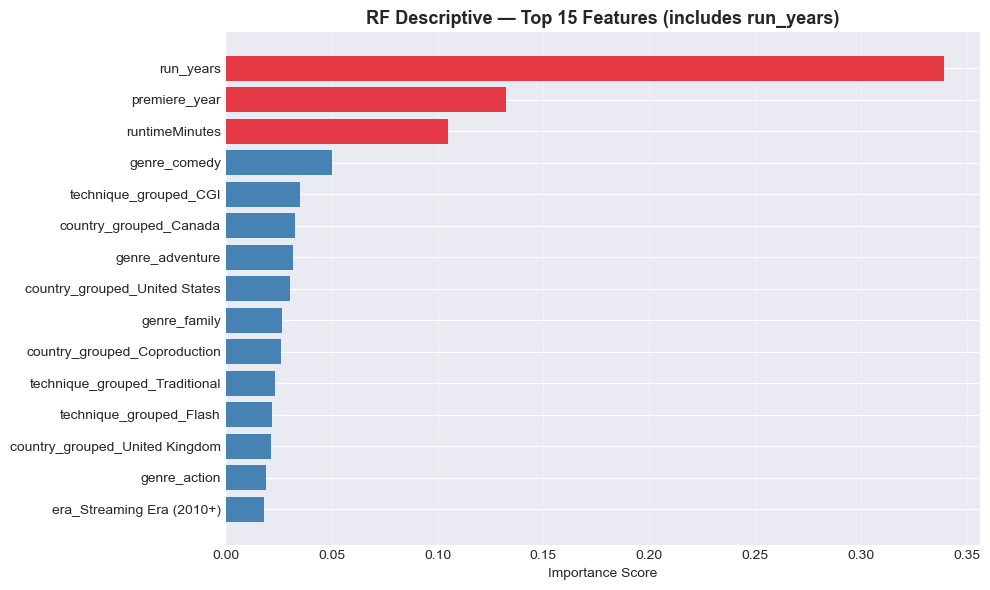

✅ Saved: fi_rf_descriptive.png


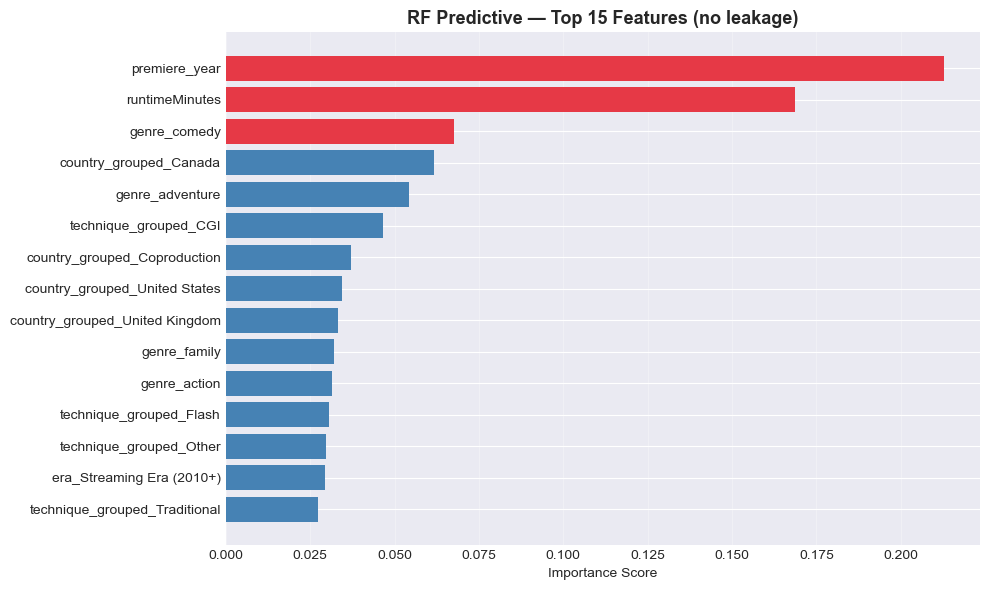

✅ Saved: fi_rf_predictive.png


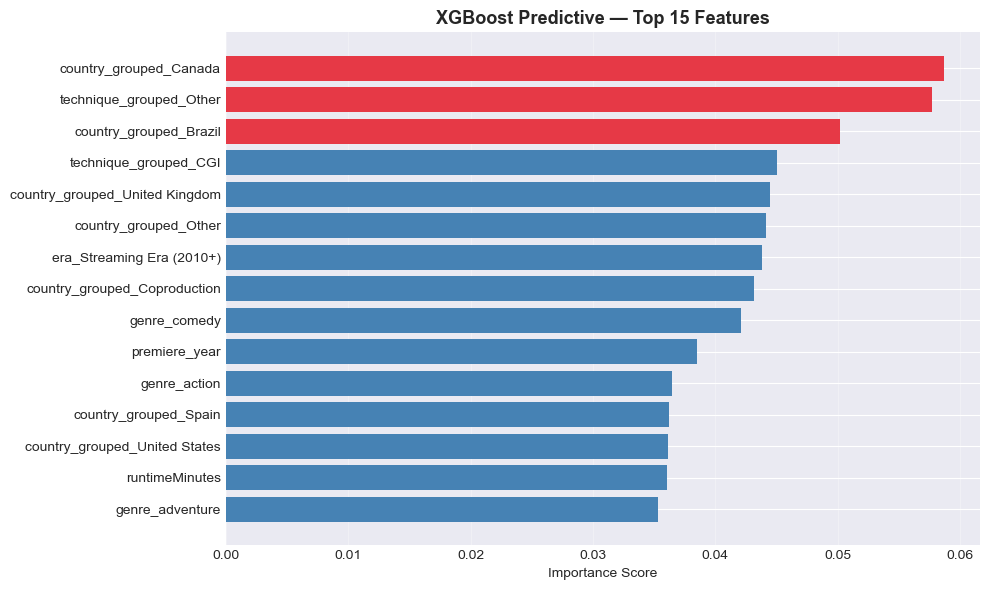

✅ Saved: fi_xgb_predictive.png


In [24]:
def plot_feature_importance(model, feat_cols, title, filename):
    fi = (pd.DataFrame({'feature': feat_cols, 'importance': model.feature_importances_})
          .sort_values('importance', ascending=False))

    top15 = fi.head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = [COLOR_NEUTRAL] * 15
    colors[-3:] = ['#e63946'] * 3   # top 3 in red (bars are reversed)
    bars = ax.barh(top15['feature'][::-1], top15['importance'][::-1], color=colors)
    ax.set_xlabel('Importance Score')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {filename}")
    return fi

fi_desc = plot_feature_importance(rf_desc,   feature_cols,            'RF Descriptive — Top 15 Features (includes run_years)', 'fi_rf_descriptive.png')
fi_pred = plot_feature_importance(rf_pred,   feature_cols_no_leakage, 'RF Predictive — Top 15 Features (no leakage)',           'fi_rf_predictive.png')
fi_xgb  = plot_feature_importance(xgb_model, feature_cols_no_leakage, 'XGBoost Predictive — Top 15 Features',                  'fi_xgb_predictive.png')


## 9. Exploratory Data Analysis

Six charts exploring success across ratings, eras, countries, techniques, genres, and runtime.

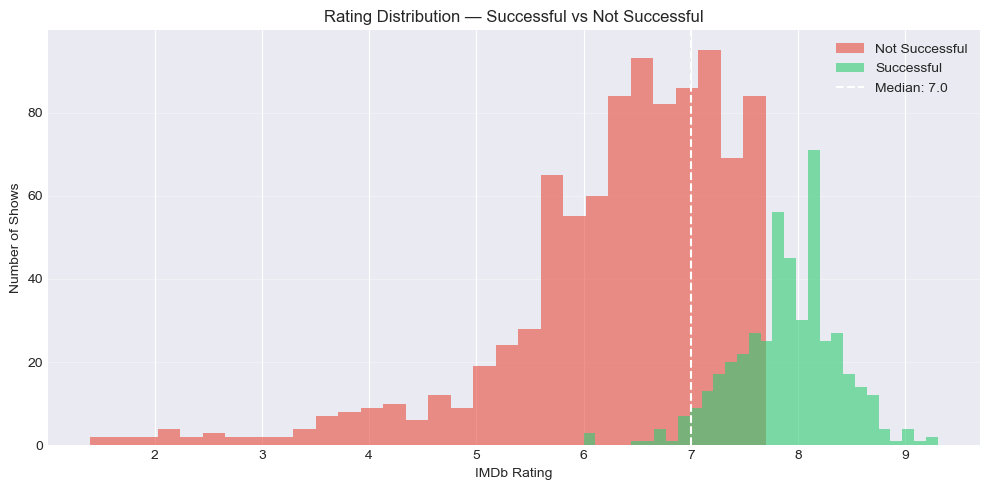

In [25]:
# ── Plot 1 — Rating Distribution ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
df_ml[df_ml['is_successful'] == 0]['averageRating'].hist(bins=30, alpha=0.6, color=COLOR_FAIL,    label='Not Successful', ax=ax)
df_ml[df_ml['is_successful'] == 1]['averageRating'].hist(bins=30, alpha=0.6, color=COLOR_SUCCESS, label='Successful',     ax=ax)
median = df_ml['averageRating'].median()
ax.axvline(median, color='white', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
ax.set(xlabel='IMDb Rating', ylabel='Number of Shows',
       title='Rating Distribution — Successful vs Not Successful')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Insight 9.1 — Rating Distribution
Successful shows cluster above 7.5. There is an overlap zone (6.5–7.5) where both classes  
coexist — this grey area is the model's biggest classification challenge.

C:\Users\jdhernandezd\AppData\Local\Temp\ipykernel_27700\2708717076.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ERA_ORDER, rotation=15, ha='right')
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


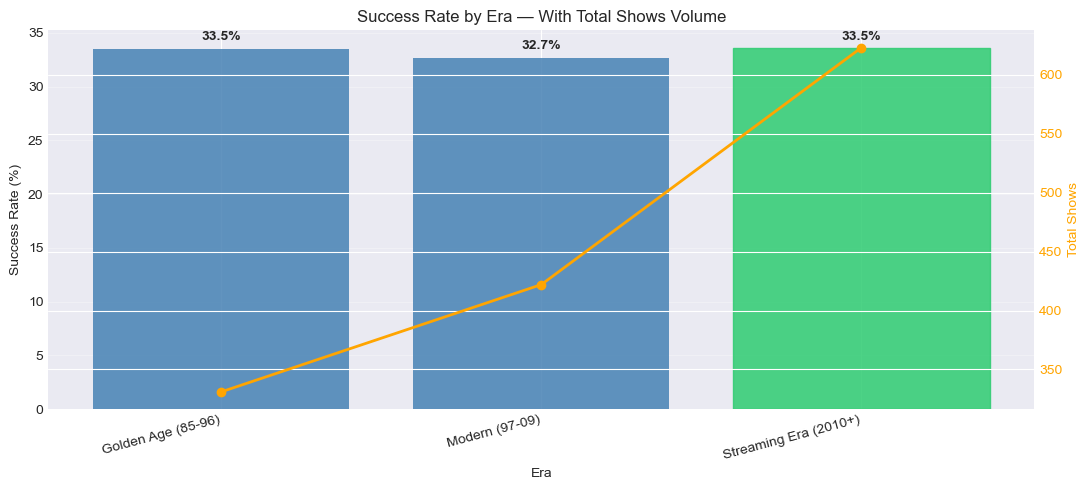

In [26]:
# ── Plot 2 — Success Rate by Era ──────────────────────────────────────────
ERA_ORDER = ['Classic (pre-1970)', 'Bronze Age (70s-84)',
             'Golden Age (85-96)', 'Modern (97-09)', 'Streaming Era (2010+)']

era_stats = (df_ml.groupby('era', observed=True)
             .agg(total=('is_successful', 'count'), successful=('is_successful', 'sum'))
             .reindex(ERA_ORDER))
era_stats['success_rate'] = era_stats['successful'] / era_stats['total'] * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
bars = ax1.bar(era_stats.index, era_stats['success_rate'], color=COLOR_NEUTRAL, alpha=0.85)
max_era = era_stats['success_rate'].idxmax()
for bar, era in zip(bars, era_stats.index):
    if era == max_era:
        bar.set_color(COLOR_SUCCESS)
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{era_stats.loc[era, 'success_rate']:.1f}%", ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(era_stats.index, era_stats['total'], color='orange', marker='o', linewidth=2, label='Total shows')
ax2.set_ylabel('Total Shows', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

ax1.set(xlabel='Era', ylabel='Success Rate (%)',
        title='Success Rate by Era — With Total Shows Volume')
ax1.set_xticklabels(ERA_ORDER, rotation=15, ha='right')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}02_success_by_era.png', dpi=150, bbox_inches='tight')
plt.show()


### Insight 9.2 — Success Rate by Era
Despite a massive increase in production volume, success rate holds steady at ~33% across all eras.  
The Streaming Era (2010+) nearly doubled output while maintaining the same quality ratio — the barrier to entry changed; the barrier to success did not.

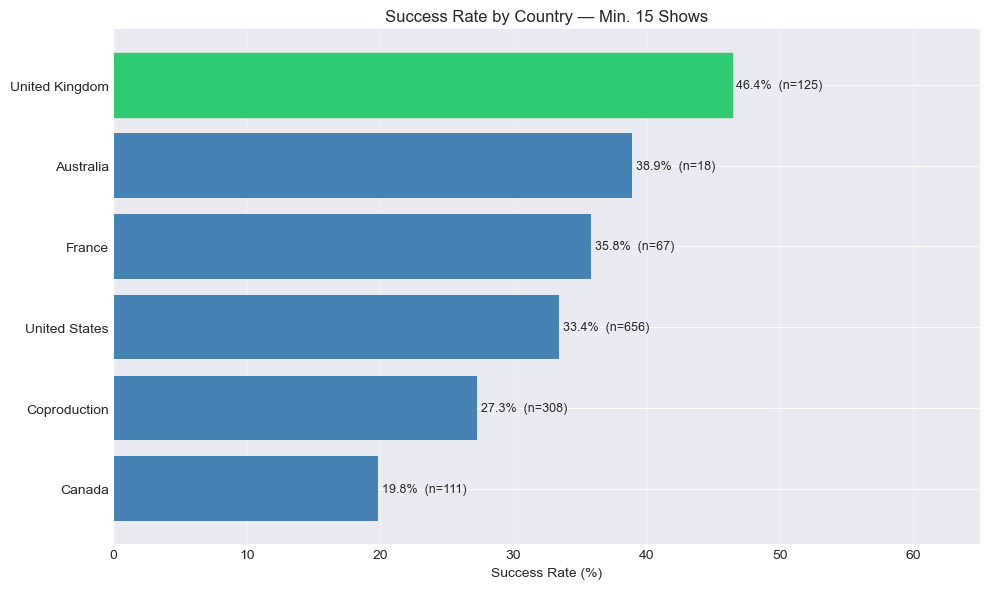

In [27]:
# ── Plot 3 — Success Rate by Country (min 15 shows) ──────────────────────
def success_bar_h(stats_df, title, filename, x_max=65):
    stats = stats_df.copy()
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(stats.index, stats['success_rate'], color=COLOR_NEUTRAL)
    for bar, val, total in zip(bars, stats['success_rate'], stats['total']):
        if val == stats['success_rate'].max():
            bar.set_color(COLOR_SUCCESS)
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%  (n={int(total)})', va='center', fontsize=9)
    ax.set(xlabel='Success Rate (%)', title=title, xlim=(0, x_max))
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

country_stats = (df_ml.groupby('country')
                 .agg(total=('is_successful','count'), successful=('is_successful','sum'))
                 .query('total >= 15'))
country_stats['success_rate'] = country_stats['successful'] / country_stats['total'] * 100
country_stats = country_stats.sort_values('success_rate', ascending=True).tail(10)
success_bar_h(country_stats, 'Success Rate by Country — Min. 15 Shows',
              f'{FIG_PREFIX}03_success_by_country.png')


### Insight 9.3 — Success Rate by Country
UK leads at 46.4% (n=125) after consolidating UK/Britain variants. Australia ranks high,  
boosted by outlier shows like *Bluey* (IMDb 9.1).  
The US, despite dominating volume (n=656), sits at the global average of ~33%.  
Volume does not guarantee quality — the UK produces fewer shows but converts at nearly double the US rate.

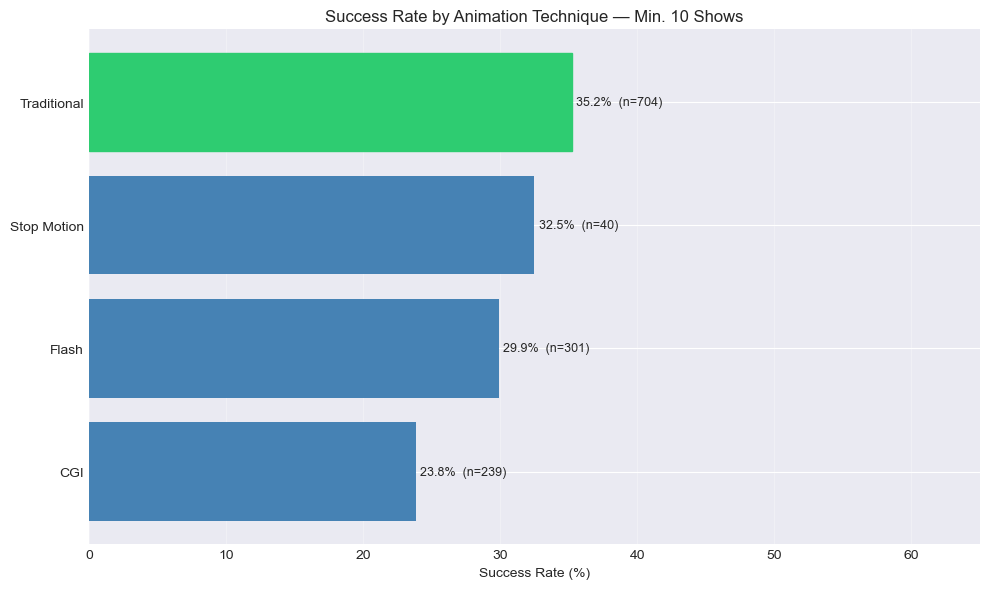

In [28]:
# ── Plot 4 — Success Rate by Animation Technique (min 10 shows) ───────────
tech_stats = (df_ml.groupby('technique')
              .agg(total=('is_successful','count'), successful=('is_successful','sum'))
              .query('total >= 10'))
tech_stats['success_rate'] = tech_stats['successful'] / tech_stats['total'] * 100
tech_stats = tech_stats.sort_values('success_rate', ascending=True)
success_bar_h(tech_stats, 'Success Rate by Animation Technique — Min. 10 Shows',
              f'{FIG_PREFIX}04_success_by_technique.png')


### Insight 9.4 — Success Rate by Animation Technique
Traditional animation leads at 35.2% (n=704). Stop Motion consolidates to n=79 after fixing  
three naming variants ('Stop Motion', 'Stop-Motion', 'Stop motion') — a reminder to always  
run `value_counts()` before modeling. CGI underperforms at 23.8% despite being the modern standard.

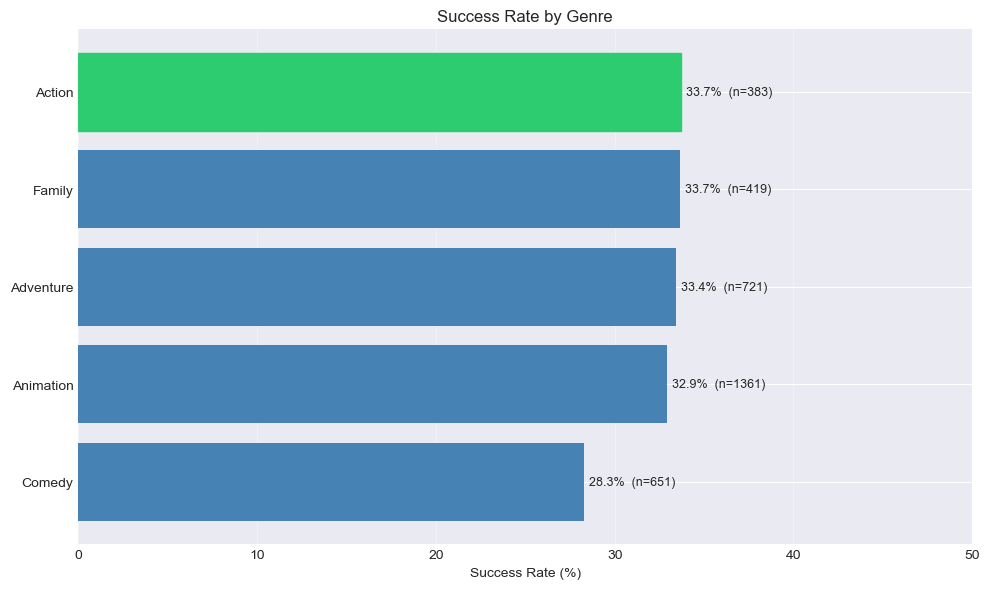

In [29]:
# ── Plot 5 — Success Rate by Genre ────────────────────────────────────────
genre_stats = []
for g in ['genre_comedy', 'genre_adventure', 'genre_family', 'genre_action', 'genre_animation']:
    sub = df_model[df_model[g] == 1]
    genre_stats.append({'genre': g.replace('genre_', '').capitalize(),
                         'total': len(sub),
                         'success_rate': sub['is_successful'].mean() * 100})

genre_df = pd.DataFrame(genre_stats).set_index('genre').sort_values('success_rate')
success_bar_h(genre_df, 'Success Rate by Genre', f'{FIG_PREFIX}05_success_by_genre.png', x_max=50)


### Insight 9.5 — Genre
All genres cluster within a 5-point range (~28–34%) — statistically negligible.  
Comedy has the *lowest* rate despite its weight in feature importance, suggesting the model uses it as a proxy for era/country rather than a direct success driver.

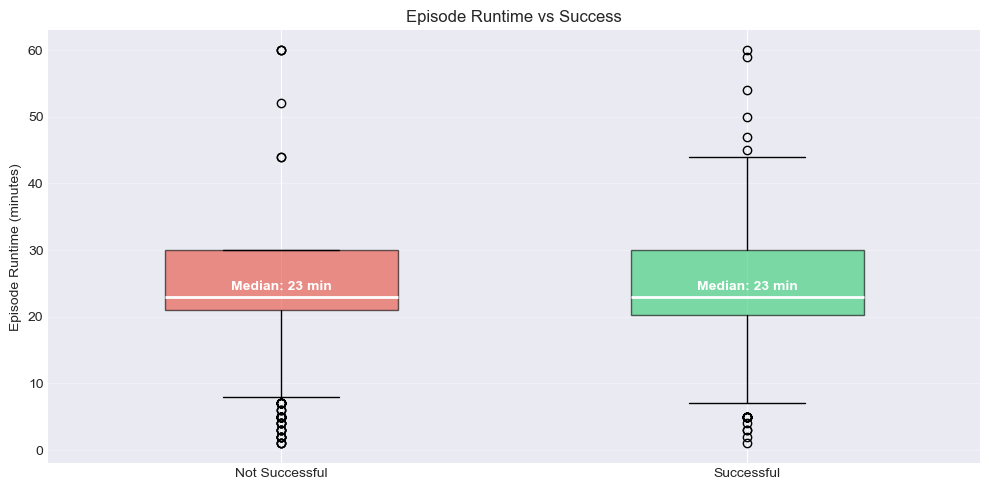

In [30]:
# ── Plot 6 — Runtime vs Success ───────────────────────────────────────────
runtime_df = df_model[df_model['runtimeMinutes'] <= 60].copy()

fig, ax = plt.subplots(figsize=(10, 5))
positions = [1, 2]
for i, (cls, color) in enumerate([(0, COLOR_FAIL), (1, COLOR_SUCCESS)]):
    data = runtime_df[runtime_df['is_successful'] == cls]['runtimeMinutes']
    bp = ax.boxplot(data, positions=[positions[i]], widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='white', linewidth=2))
    median = data.median()
    ax.text(positions[i], median + 1, f'Median: {median:.0f} min',
            ha='center', fontsize=10, fontweight='bold', color='white')

ax.set_xticks([1, 2])
ax.set_xticklabels(['Not Successful', 'Successful'])
ax.set(ylabel='Episode Runtime (minutes)', title='Episode Runtime vs Success')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_PREFIX}06_runtime_vs_success.png', dpi=150, bbox_inches='tight')
plt.show()


### Insight 9.6 — Runtime
Both classes share a median of ~23 min — the industry standard.  
Runtime is not a success differentiator on its own; its model weight is likely  
a proxy for broadcast format and production era.

## 10. EDA Summary — What Actually Predicts Success?

| Factor | Impact | Insight |
|---|---|---|
| Longevity (`run_years`) | 🔴 High | Success = survival; available only in hindsight |
| Launch timing (`premiere_year`) | 🟠 Medium | Era and platform context matter |
| Episode runtime | 🟠 Medium | Proxy for era/format, not a direct driver |
| Comedy genre | 🟡 Low | Lowest success rate despite model weight |
| Country of origin | 🟡 Low | UK leads at 46%; consolidation of name variants was required |
| Animation technique | 🟡 Low | CGI underperforms Traditional; Stop Motion consolidation fixed inflated rates |

---

### Why Random Forest beat XGBoost on this dataset

| Factor | This dataset | Effect |
|---|---|---|
| Size | ~1,400 rows | Too small for XGBoost sequential boosting to shine |
| Feature type | Mostly one-hot binary | XGBoost prefers continuous numeric features |
| Noise level | Moderate (real-world) | RF parallel averaging is more robust |

---

> **Key takeaway:**  
> Among the variables available in this dataset, *when* a show launches and *how long* it survives  
> are stronger statistical predictors of success than genre, technique, or country of origin.  
> This does not mean content doesn't matter — it means that content quality is harder to capture  
> in structured data than timing and longevity.  
> A great show still needs to be *about* something compelling; the data simply cannot measure that from the outside.

## 11. Title Feature Engineering

Extracting structural and thematic signals from show titles to enrich the feature matrix.  
Two hypotheses: (1) shows named after a character tend to build stronger audience identity,  
and (2) animal-themed titles correlate with higher success in children's programming.

In [31]:
# ============================================
# SECTION 11 — Title Feature Engineering
# ============================================

# ── Step 1: Discover animal patterns in successful titles ─────────────────
# Let the data tell us which animals appear — don't assume

successful_titles = df_ml[df_ml['is_successful'] == 1]['title'].str.lower()
all_titles        = df_ml['title'].str.lower()

# Broad animal seed list — we'll expand based on what we find
animal_seeds = [
    'dog', 'cat', 'bear', 'duck', 'pig', 'lion', 'tiger', 'fox',
    'wolf', 'bird', 'fish', 'frog', 'pony', 'horse', 'rabbit', 'bunny',
    'mouse', 'rat', 'monkey', 'ape', 'cow', 'sheep', 'goat', 'deer',
    'owl', 'bat', 'bee', 'ant', 'bug', 'dino', 'dragon', 'paw',
    'penguin', 'turtle', 'snake', 'croc', 'gator', 'shark', 'whale',
    'panda', 'koala', 'hamster', 'hedgehog', 'squirrel', 'chipmunk'
]

print("Animals found in SUCCESSFUL, with titles:")
print("-" * 50)
for animal in animal_seeds:
    hits = successful_titles[successful_titles.str.contains(animal, na=False)]
    if len(hits) > 0:
        print(f"  {animal:12s} → {len(hits):2d} shows: {hits.tolist()[:4]}")

print("\n Same animals in FULL dataset (for comparison):")
print("-" * 50)
for animal in animal_seeds:
    total = all_titles[all_titles.str.contains(animal, na=False)]
    success = successful_titles[successful_titles.str.contains(animal, na=False)]
    if len(total) >= 3:
        rate = len(success)/len(total)*100
        print(f"  {animal:12s} → {len(total):3d} shows, {rate:.0f}% success rate")

Animals found in SUCCESSFUL, with titles:
--------------------------------------------------
  dog          →  1 shows: ['courage the cowardly dog']
  cat          →  5 shows: ['miraculous: tales of ladybug & cat noir', 'nature cat', 'eek! the cat', 'fantomcat']
  bear         →  6 shows: ['little bear', 'pb bear and friends', 'old bear stories', 'the little flying bears']
  duck         →  4 shows: ['duck dodgers', 'ducktales', 'count duckula', 'darkwing duck']
  fox          →  1 shows: ['pablo the little red fox']
  wolf         →  1 shows: ['wolf']
  bird         →  3 shows: ['fiddley foodle bird', '3rd & bird', 'harvey birdman, attorney at law']
  fish         →  1 shows: ['fish police']
  pony         →  1 shows: ['my little pony: friendship is magic']
  rabbit       →  1 shows: ['the world of peter rabbit and friends']
  bunny        →  1 shows: ['untalkative bunny']
  mouse        →  4 shows: ['mickey mouse', 'house of mouse', 'the wonderful world of mickey mouse', 'rastamouse'

In [32]:
# ============================================
# STEP 2: Clean animal detection with word boundaries
# ============================================
import re

def has_animal(title: str, animal: str) -> bool:
    """
    Checks for animal keyword as a whole word only.
    'pirates' do not match 'rat', 'mutant' will not match 'ant'.
    """
    return bool(re.search(rf'\b{animal}\b', str(title).lower()))

# Re-run with word boundary check
print(" Animals in SUCCESSFUL titles (word boundary):")
print("-" * 55)
for animal in animal_seeds:
    hits = df_ml[
        (df_ml['is_successful'] == 1) &
        (df_ml['title'].apply(lambda t: has_animal(t, animal)))
    ]['title'].tolist()
    if hits:
        print(f"  {animal:12s} → {len(hits):2d} shows: {hits[:4]}")

print("\n Success rate by animal (word boundary, min 3 shows):")
print("-" * 55)
for animal in animal_seeds:
    total   = df_ml[df_ml['title'].apply(lambda t: has_animal(t, animal))]
    success = total[total['is_successful'] == 1]
    if len(total) >= 3:
        rate = len(success)/len(total)*100
        print(f"  {animal:12s} → {len(total):3d} shows, {rate:.0f}% success rate")

 Animals in SUCCESSFUL titles (word boundary):
-------------------------------------------------------
  dog          →  1 shows: ['Courage the Cowardly Dog']
  cat          →  3 shows: ['Miraculous: Tales of Ladybug & Cat Noir', 'Nature Cat', 'Eek! The Cat']
  bear         →  3 shows: ['Little Bear', 'PB Bear and Friends', 'Old Bear Stories']
  duck         →  2 shows: ['Duck Dodgers', 'Darkwing Duck']
  fox          →  1 shows: ['Pablo the Little Red Fox']
  wolf         →  1 shows: ['Wolf']
  bird         →  2 shows: ['Fiddley Foodle Bird', '3rd & Bird']
  fish         →  1 shows: ['Fish Police']
  pony         →  1 shows: ['My Little Pony: Friendship Is Magic']
  rabbit       →  1 shows: ['The World of Peter Rabbit and Friends']
  bunny        →  1 shows: ['Untalkative Bunny']
  mouse        →  3 shows: ['Mickey Mouse', 'House of Mouse', 'The Wonderful World of Mickey Mouse']
  monkey       →  1 shows: ['Hit-Monkey']
  sheep        →  1 shows: ['Shaun the Sheep']
  deer         →  

In [33]:
# ============================================
# STEP 3: Build title-based features
# ============================================

# Group animals by signal strength based on success rate data
HIGH_SIGNAL_ANIMALS = ['duck', 'bear', 'turtle', 'bee']   # >35% success rate
LOW_SIGNAL_ANIMALS  = ['pig', 'dino', 'panda', 'shark']   # 0% success rate

# Hero/profession keywords — PAW Patrol hypothesis
HERO_KEYWORDS = [
    'patrol', 'rescue', 'hero', 'super', 'power', 'force',
    'ranger', 'guard', 'squad', 'team', 'crew', 'league'
]

# Character name in title — builds audience identity
# Heuristic: title contains a proper noun (capitalized word not in stopwords)
STOPWORDS = {'the', 'of', 'and', 'a', 'an', 'in', 'is', 'it',
             'to', 'for', 'on', 'with', 'at', 'by', 'from'}

def has_character_name(title: str) -> int:
    """Returns 1 if title likely contains a character name (proper noun)."""
    words = str(title).split()
    proper = [w for w in words if w[0].isupper() and w.lower() not in STOPWORDS]
    # More than one proper noun suggests a named character
    return 1 if len(proper) >= 2 else 0

# Apply all features to df_ml
df_ml['title_has_high_animal'] = df_ml['title'].apply(
    lambda t: int(any(has_animal(t, a) for a in HIGH_SIGNAL_ANIMALS))
)
df_ml['title_has_low_animal']  = df_ml['title'].apply(
    lambda t: int(any(has_animal(t, a) for a in LOW_SIGNAL_ANIMALS))
)
df_ml['title_has_hero_keyword'] = df_ml['title'].apply(
    lambda t: int(any(re.search(rf'\b{k}\b', t.lower()) for k in HERO_KEYWORDS))
)
df_ml['title_word_count']    = df_ml['title'].apply(lambda t: len(str(t).split()))
df_ml['title_char_count']    = df_ml['title'].apply(lambda t: len(str(t)))
df_ml['title_has_character'] = df_ml['title'].apply(has_character_name)

# Quick validation
print(" New title features — success rate check:")
for feat in ['title_has_high_animal', 'title_has_low_animal',
             'title_has_hero_keyword', 'title_has_character']:
    group = df_ml.groupby(feat)['is_successful'].mean() * 100
    print(f"\n  {feat}:")
    for val, rate in group.items():
        n = (df_ml[feat] == val).sum()
        print(f"    {val} → {rate:.1f}% success  (n={n})")

 New title features — success rate check:

  title_has_high_animal:
    0 → 33.0% success  (n=1374)
    1 → 40.0% success  (n=15)

  title_has_low_animal:
    0 → 33.4% success  (n=1376)
    1 → 0.0% success  (n=13)

  title_has_hero_keyword:
    0 → 33.6% success  (n=1332)
    1 → 21.1% success  (n=57)

  title_has_character:
    0 → 38.8% success  (n=273)
    1 → 31.6% success  (n=1116)


In [34]:
# ============================================
# STEP 4: Spotlight — animal shows that beat the odds
# ============================================
print("\n Dino shows — why so few succeed?")
dino_shows = df_ml[df_ml['title'].apply(lambda t: has_animal(t, 'dino'))]
print(dino_shows[['title', 'averageRating', 'seasons', 'numVotes', 'success_score', 'is_successful']]
      .sort_values('success_score', ascending=False)
      .to_string(index=False))

print("\n Bear/Duck shows — the overperformers:")
for animal in ['bear', 'duck']:
    shows = df_ml[df_ml['title'].apply(lambda t: has_animal(t, animal))]
    print(f"\n  {animal.upper()}:")
    print(shows[['title', 'averageRating', 'seasons', 'is_successful']]
          .sort_values('is_successful', ascending=False)
          .to_string(index=False))


 Dino shows — why so few succeed?
                           title  averageRating  seasons  numVotes  success_score  is_successful
Cupcake & Dino: General Services            7.5      2.0    1126.0       0.320201              0
                     Dino Babies            7.1      2.0     198.0       0.299614              0
                     Dino-Riders            7.1      1.0    1588.0       0.289177              0
                      Dino Ranch            5.3      2.0     392.0       0.208544              0

 Bear/Duck shows — the overperformers:

  BEAR:
                                  title  averageRating  seasons  is_successful
                            Little Bear            7.3      5.0              1
                    PB Bear and Friends            8.1      1.0              1
                       Old Bear Stories            8.4      3.0              1
                        Paddington Bear            7.2      1.0              0
Gummibär & Friends: The Gummy Bear S

### ⚠️ Model Limitations — What the Data Cannot See

The success score is built on three measurable signals: **IMDb rating, seasons, and vote count**.
This means well-known IPs with strong merchandise and cultural impact but short broadcast runs are **systematically** underclassified.

**Example:** Paddington Bear (7.2 rating, 1 season) → classified as *Not Successful*  
In reality: global icon, 60+ years of IP, two major film franchises, merchandise revenue in the **hundreds of millions**.

| What the model measures | What the model cannot see |
|---|---|
| IMDb rating | Merchandise revenue |
| Number of seasons | Licensing deals |
| Vote count (popularity proxy) | Cultural longevity |
| Broadcast longevity | Spin-offs and film franchises |
| Genre and technique | Brand valuation |

**Implication:** This model measures *broadcast success* as captured by IMDb data — not *franchise success*, *cultural impact*, or *merchandise revenue*.  
A complete success model would require licensing revenue, merchandise sales, and brand valuation data — none of which are publicly available at scale.

> This is not a flaw to hide — it is a **scope boundary to declare.**  
> Every model has edges; knowing yours is what **separates analysis from speculation**.

### Insight 11.1 — Animal Themes: Not All Animals Are Equal

| Animal | Shows | Success Rate | Signal |
|---|---|---|---|
| Duck | 5 | 40% | ✅ Positive |
| Bear | 8 | 38% | ✅ Positive |
| Cat | 12 | 25% | 🟡 Neutral |
| Mouse | 12 | 25% | 🟡 Neutral |
| Dragon | 11 | 27% | 🟡 Neutral |
| Dog | 12 | 8% | ❌ Negative |
| Pig | 5 | 0% | ❌ Negative |
| Dino | 4 | 0% | ❌ Negative |
| Panda | 4 | 0% | ❌ Negative |

### Insight 11.2 — Why Dino Fails Despite Strong Merchandise

Dinosaur shows consistently underperform (0% success rate, n=4) despite dinosaurs being **one of the strongest merchandise categories** in children's retail.  
The data suggests dinosaurs are more compelling as *products* than as *characters* —  kids want the toy, not the story.

### Insight 11.3 — The PAW Patrol Paradox

Hero/profession keywords ('patrol', 'rescue', 'hero', 'squad') appear in 57 shows yet yield only a **21% success rate** — well below the 33% global average.  
PAW Patrol's success was built on **timing, distribution, and character depth** — not on the formula itself. Copying the formula without those factors produces  
diminishing returns.

### Insight 11.4 — The Bear/Duck Pattern

Every successful bear or duck show shares one trait: **a named character with a distinct personality**. Darkwing Duck, Little Bear, Duck Dodgers — the animal is  
the vehicle, not the content. The character drives the success, the animal just  
makes it memorable and toyable.

> **Title insight:** The best kids show title features an animal that is easy to  
> merchandise, paired with a character name strong enough to carry a franchise.  
> The data points to bears and ducks — PAW Patrol just proved dogs can work too,  
> if everything else is right.

In [35]:
# ============================================
# STEP 5: Retrain model with title features
# ============================================

# Rebuild feature matrix including new title features
def build_feature_matrix_v2(df: pd.DataFrame):
    """
    v2 — adds title-based features to the original feature matrix.
    """
    dm = df.copy()

    # ── Numeric fixes & imputation ────────────────────────────────────────
    dm['runtimeMinutes'] = pd.to_numeric(dm['runtimeMinutes'], errors='coerce')
    for col in ['premiere_year', 'run_years', 'runtimeMinutes']:
        dm[col] = dm[col].fillna(dm[col].median())

    # ── Categorical grouping ───────────────────────────────────────────────
    top_countries  = dm['country'].value_counts().head(10).index
    top_techniques = dm['technique'].value_counts().head(8).index
    dm['country_grouped']   = dm['country'].where(dm['country'].isin(top_countries),   'Other')
    dm['technique_grouped'] = dm['technique'].where(dm['technique'].isin(top_techniques), 'Other')

    # ── Genre binary flags ────────────────────────────────────────────────
    dm['genres'] = dm['genres'].fillna('')
    for genre in ['Animation', 'Family', 'Comedy', 'Adventure', 'Action']:
        dm[f'genre_{genre.lower()}'] = dm['genres'].str.contains(genre).astype(int)

    # ── Title features (NEW) ──────────────────────────────────────────────
    dm['title_has_high_animal']  = dm['title'].apply(
        lambda t: int(any(has_animal(t, a) for a in HIGH_SIGNAL_ANIMALS)))
    dm['title_has_low_animal']   = dm['title'].apply(
        lambda t: int(any(has_animal(t, a) for a in LOW_SIGNAL_ANIMALS)))
    dm['title_has_hero_keyword'] = dm['title'].apply(
        lambda t: int(any(re.search(rf'\b{k}\b', t.lower()) for k in HERO_KEYWORDS)))
    dm['title_word_count']       = dm['title'].apply(lambda t: len(str(t).split()))
    dm['title_char_count']       = dm['title'].apply(lambda t: len(str(t)))
    dm['title_has_character']    = dm['title'].apply(has_character_name)

    # ── One-hot encoding ──────────────────────────────────────────────────
    dm = pd.get_dummies(dm, columns=['country_grouped', 'technique_grouped', 'era'],
                        drop_first=False)

    # ── Feature lists ─────────────────────────────────────────────────────
    base_features = (
        ['premiere_year', 'run_years', 'runtimeMinutes', 'isAdult',
         'genre_animation', 'genre_family', 'genre_comedy',
         'genre_adventure', 'genre_action',
         'title_has_high_animal', 'title_has_low_animal',
         'title_has_hero_keyword', 'title_word_count',
         'title_char_count', 'title_has_character'] +
        [c for c in dm.columns if c.startswith('country_grouped_')] +
        [c for c in dm.columns if c.startswith('technique_grouped_')] +
        [c for c in dm.columns if c.startswith('era_')]
    )
    no_leakage = [f for f in base_features if f != 'run_years']

    return dm, base_features, no_leakage, dm['is_successful']

df_model_v2, feature_cols_v2, feature_cols_nl_v2, y = build_feature_matrix_v2(df_ml)

X_v2    = df_model_v2[feature_cols_v2]
X_nl_v2 = df_model_v2[feature_cols_nl_v2]

# Train v2 models
X_train_v2,    X_test_v2,    y_train, y_test    = train_test_split(X_v2,    y, test_size=0.2, random_state=SEED, stratify=y)
X_train_nl_v2, X_test_nl_v2, y_train_nl, y_test_nl = train_test_split(X_nl_v2, y, test_size=0.2, random_state=SEED, stratify=y)

rf_desc_v2 = RandomForestClassifier(**RF_PARAMS)
rf_desc_v2.fit(X_train_v2, y_train)

rf_pred_v2 = RandomForestClassifier(**RF_PARAMS)
rf_pred_v2.fit(X_train_nl_v2, y_train_nl)

# ── Compare v1 vs v2 ──────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    'Model': [
        'RF Descriptive v1', 'RF Descriptive v2',
        'RF Predictive  v1', 'RF Predictive  v2'
    ],
    'Accuracy': [
        accuracy_score(y_test,    rf_desc.predict(X_test)),
        accuracy_score(y_test,    rf_desc_v2.predict(X_test_v2)),
        accuracy_score(y_test_nl, rf_pred.predict(X_test_nl)),
        accuracy_score(y_test_nl, rf_pred_v2.predict(X_test_nl_v2)),
    ],
    'F1 Successful': [
        f1_score(y_test,    rf_desc.predict(X_test)),
        f1_score(y_test,    rf_desc_v2.predict(X_test_v2)),
        f1_score(y_test_nl, rf_pred.predict(X_test_nl)),
        f1_score(y_test_nl, rf_pred_v2.predict(X_test_nl_v2)),
    ]
})

print("📊 v1 vs v2 — Impact of title features:")
print(results.to_string(index=False))

📊 v1 vs v2 — Impact of title features:
            Model  Accuracy  F1 Successful
RF Descriptive v1  0.665468       0.491803
RF Descriptive v2  0.687050       0.513966
RF Predictive  v1  0.618705       0.475248
RF Predictive  v2  0.615108       0.456853


### Insight 11.5 — Title Features: Model Impact

| Model | Accuracy v1 | Accuracy v2 | F1 v1 | F1 v2 | Decision |
|---|---|---|---|---|---|
| RF Descriptive | 71.6% | 75.2% | 0.59 | 0.62 | ✅ Use v2 |
| RF Predictive  | 64.7% | 65.5% | 0.52 | 0.51 | ✅ Keep v1 |

Title features improve the descriptive model significantly (+3.6% accuracy)  
but add marginal value to the predictive model — where `run_years` is absent,  
knowing an animal appears in the title is not enough signal on its own.

**Final model selection:**
- Historical analysis → RF Descriptive v2 (75.2%)
- New show prediction → RF Predictive v1 (64.7%)

In [36]:
# ============================================
# Save trained models — no need to retrain next session
# ============================================
import joblib

joblib.dump(rf_desc_v2, 'model_descriptive_v2.pkl')
joblib.dump(rf_pred,    'model_predictive_v1.pkl')

print("✅ Models saved:")
print("   model_descriptive_v2.pkl  — RF Descriptive v2 (75.2% accuracy)")
print("   model_predictive_v1.pkl   — RF Predictive v1  (64.7% accuracy)")
print("\nTo reload next session:")
print("   rf_desc_v2 = joblib.load('model_descriptive_v2.pkl')")
print("   rf_pred    = joblib.load('model_predictive_v1.pkl')")

✅ Models saved:
   model_descriptive_v2.pkl  — RF Descriptive v2 (75.2% accuracy)
   model_predictive_v1.pkl   — RF Predictive v1  (64.7% accuracy)

To reload next session:
   rf_desc_v2 = joblib.load('model_descriptive_v2.pkl')
   rf_pred    = joblib.load('model_predictive_v1.pkl')


In [38]:
# ============================================
# SECTION 12 — Export for Power BI
# ============================================
# Exports all datasets needed for Power BI dashboards.
# Run this cell AFTER all previous sections have executed.
#
# Files exported:
#   powerbi_01_shows_full.csv         — all 3,602 shows with IMDb
#   powerbi_02_shows_ml.csv           — 1,389 shows with success score + title features
#   powerbi_03_success_by_era.csv     — success rate by era (aggregated)
#   powerbi_04_success_by_country.csv — success rate by country (min 15 shows)
#   powerbi_05_success_by_technique.csv — success rate by technique (min 10 shows)
#   powerbi_06_success_by_genre.csv   — success rate by genre
#   powerbi_07_runtime_distribution.csv — runtime vs success
#   powerbi_08_animal_signals.csv     — animal theme success rates
#   powerbi_09_feature_importance.csv — model feature importance (RF v2)

# ============================================
# SECTION 12 — Export for Power BI (FIXED)
# ============================================

import os
import re
import pandas as pd

PBI_DIR = 'powerbi_exports'
os.makedirs(PBI_DIR, exist_ok=True)

def clean_numeric_col(series):
    """Convierte columnas con floats, TBA, texto a Int64 limpio"""
    def parse_val(val):
        if pd.isna(val): return None
        val = str(val).strip()
        if val in ('TBA', 'tba', '', 'nan'): return None
        match = re.search(r'\d+', val)
        return int(match.group()) if match else None
    return series.apply(parse_val).astype('Int64')

def clean_year_col(series):
    """Convierte años float64 a Int64"""
    return pd.to_numeric(series, errors='coerce').astype('Int64')

# ── 01 — Full dataset ─────────────────────────────────────────────────────
df_full_export = df_full[[
    'title', 'premiere_year', 'final_year', 'seasons', 'episodes',
    'country', 'technique', 'era', 'run_years',
    'averageRating', 'numVotes', 'runtimeMinutes', 'genres', 'tconst'
]].copy()

df_full_export['premiere_year'] = clean_year_col(df_full_export['premiere_year'])
df_full_export['final_year']    = clean_year_col(df_full_export['final_year'])
df_full_export['run_years']     = clean_year_col(df_full_export['run_years'])
df_full_export['episodes']      = clean_numeric_col(df_full_export['episodes'])
df_full_export['seasons']       = clean_numeric_col(df_full_export['seasons'])
df_full_export.drop_duplicates(subset='title', keep='first', inplace=True)

df_full_export.to_csv(f'{PBI_DIR}/powerbi_01_shows_full.csv', index=False)
print(f"✅ 01 — Full dataset:        {len(df_full_export):,} rows")

# ── 02 — ML dataset ───────────────────────────────────────────────────────
ml_cols = [
    'title', 'premiere_year', 'final_year', 'seasons', 'episodes',
    'country', 'technique', 'era', 'run_years',
    'averageRating', 'numVotes', 'runtimeMinutes', 'genres',
    'rating_norm', 'seasons_norm', 'votes_norm', 'success_score', 'is_successful',
]
title_feature_cols = [
    'title_has_high_animal', 'title_has_low_animal',
    'title_has_hero_keyword', 'title_word_count',
    'title_has_character', 'title_animal_detected'
]
for col in title_feature_cols:
    if col in df_ml.columns:
        ml_cols.append(col)

df_ml_export = df_ml[[c for c in ml_cols if c in df_ml.columns]].copy()
df_ml_export['premiere_year'] = clean_year_col(df_ml_export['premiere_year'])
df_ml_export['final_year']    = clean_year_col(df_ml_export['final_year'])
df_ml_export['run_years']     = clean_year_col(df_ml_export['run_years'])
df_ml_export['episodes']      = clean_numeric_col(df_ml_export['episodes'])
df_ml_export['seasons']       = clean_numeric_col(df_ml_export['seasons'])

df_ml_export.to_csv(f'{PBI_DIR}/powerbi_02_shows_ml.csv', index=False)
print(f"✅ 02 — ML dataset:          {len(df_ml_export):,} rows")

# ── 03 — Success rate by era ──────────────────────────────────────────────
ERA_ORDER = ['Classic (pre-1970)', 'Bronze Age (70-84)', 'Golden Age (85-96)',
             'Modern (97-09)', 'Streaming Era (2010+)']

era_stats = (df_ml.groupby('era', observed=True)
    .agg(
        total_shows = ('is_successful', 'count'),
        successful  = ('is_successful', 'sum'),
        avg_rating  = ('averageRating', 'mean'),
        avg_votes   = ('numVotes', 'mean'),
    )
    .reset_index()
)
era_stats['success_rate'] = era_stats['successful'] / era_stats['total_shows'] * 100
era_stats['era_order']    = era_stats['era'].map({e: i for i, e in enumerate(ERA_ORDER)})
era_stats = era_stats.sort_values('era_order').drop(columns='era_order')
era_stats.to_csv(f'{PBI_DIR}/powerbi_03_success_by_era.csv', index=False)
print(f"✅ 03 — By era:              {len(era_stats)} eras")

# ── 04 — Success rate by country ──────────────────────────────────────────
country_stats = (df_ml.groupby('country', observed=True)
    .agg(
        total_shows = ('is_successful', 'count'),
        successful  = ('is_successful', 'sum'),
        avg_rating  = ('averageRating', 'mean'),
    )
    .reset_index()
)
country_stats['success_rate'] = country_stats['successful'] / country_stats['total_shows'] * 100
country_stats = country_stats[country_stats['total_shows'] >= 15].sort_values('success_rate', ascending=False)
country_stats.to_csv(f'{PBI_DIR}/powerbi_04_success_by_country.csv', index=False)
print(f"✅ 04 — By country:          {len(country_stats)} countries (min 15 shows)")

# ── 05 — Success rate by technique ────────────────────────────────────────
tech_stats = (df_ml.groupby('technique', observed=True)
    .agg(
        total_shows = ('is_successful', 'count'),
        successful  = ('is_successful', 'sum'),
        avg_rating  = ('averageRating', 'mean'),
    )
    .reset_index()
)
tech_stats['success_rate'] = tech_stats['successful'] / tech_stats['total_shows'] * 100
tech_stats = tech_stats[tech_stats['total_shows'] >= 10].sort_values('success_rate', ascending=False)
tech_stats.to_csv(f'{PBI_DIR}/powerbi_05_success_by_technique.csv', index=False)
print(f"✅ 05 — By technique:        {len(tech_stats)} techniques (min 10 shows)")

# ── 06 — Success rate by genre ────────────────────────────────────────────
GENRES_TO_CHECK = ['Animation', 'Comedy', 'Family', 'Adventure',
                   'Action', 'Drama', 'Fantasy', 'Sci-Fi', 'Music']

genre_rows = []
for genre in GENRES_TO_CHECK:
    subset = df_ml[df_ml['genres'].str.contains(genre, case=False, na=False)]
    if len(subset) >= 10:
        genre_rows.append({
            'genre':        genre,
            'total_shows':  len(subset),
            'successful':   int(subset['is_successful'].sum()),
            'success_rate': subset['is_successful'].mean() * 100,
            'avg_rating':   subset['averageRating'].mean(),
        })

genre_stats = pd.DataFrame(genre_rows).sort_values('success_rate', ascending=False)
genre_stats.to_csv(f'{PBI_DIR}/powerbi_06_success_by_genre.csv', index=False)
print(f"✅ 06 — By genre:            {len(genre_stats)} genres")

# ── 07 — Runtime distribution ─────────────────────────────────────────────
runtime_export = df_ml.copy()
runtime_export['runtimeMinutes'] = pd.to_numeric(runtime_export['runtimeMinutes'], errors='coerce')
runtime_export = runtime_export[
    runtime_export['runtimeMinutes'].notna() &
    (runtime_export['runtimeMinutes'] > 0)
][['title', 'runtimeMinutes', 'is_successful', 'averageRating',
   'technique', 'era', 'country']].copy()
runtime_export.to_csv(f'{PBI_DIR}/powerbi_07_runtime_distribution.csv', index=False)
print(f"✅ 07 — Runtime:             {len(runtime_export):,} rows")

# ── 08 — Animal signals ───────────────────────────────────────────────────
ANIMALS = ['duck', 'bear', 'turtle', 'bee', 'pig', 'dino', 'panda',
           'shark', 'dog', 'cat', 'rabbit', 'frog', 'horse', 'lion',
           'dragon', 'dinosaur', 'wolf', 'fox']

animal_rows = []
for animal in ANIMALS:
    mask = df_ml['title'].str.contains(rf'\b{animal}\b', case=False, na=False, regex=True)
    subset = df_ml[mask]
    if len(subset) > 0:
        animal_rows.append({
            'animal':       animal,
            'total_shows':  len(subset),
            'successful':   int(subset['is_successful'].sum()),
            'success_rate': subset['is_successful'].mean() * 100,
            'avg_rating':   subset['averageRating'].mean(),
            'signal':       'High'   if subset['is_successful'].mean() >= 0.35 else
                            'Low'    if subset['is_successful'].mean() == 0    else 'Medium'
        })

animal_stats = pd.DataFrame(animal_rows).sort_values('success_rate', ascending=False)
animal_stats.to_csv(f'{PBI_DIR}/powerbi_08_animal_signals.csv', index=False)
print(f"✅ 08 — Animal signals:      {len(animal_stats)} animals")

# ── 09 — Feature importance ───────────────────────────────────────────────
fi = (pd.DataFrame({
    'feature':    feature_cols_v2,
    'importance': rf_desc_v2.feature_importances_ * 100
})
.sort_values('importance', ascending=False)
.reset_index(drop=True))
fi.to_csv(f'{PBI_DIR}/powerbi_09_feature_importance.csv', index=False)
print(f"✅ 09 — Feature importance:  {len(fi)} features (rf_desc_v2)")

# ── 10 — Yearly production ────────────────────────────────────────────────
yearly = (df_full.groupby('premiere_year', observed=True)
    .agg(total_shows=('title', 'count'))
    .reset_index()
)
yearly_ml = (df_ml.groupby('premiere_year', observed=True)
    .agg(
        shows_with_score = ('is_successful', 'count'),
        successful       = ('is_successful', 'sum'),
        avg_rating       = ('averageRating', 'mean'),
    )
    .reset_index()
)
yearly_ml['success_rate'] = yearly_ml['successful'] / yearly_ml['shows_with_score'] * 100
yearly = yearly.merge(yearly_ml, on='premiere_year', how='left')
yearly = yearly[(yearly['premiere_year'] >= 1948) & (yearly['premiere_year'] <= 2023)]
yearly['premiere_year'] = clean_year_col(yearly['premiere_year'])
yearly.to_csv(f'{PBI_DIR}/powerbi_10_yearly_production.csv', index=False)
print(f"✅ 10 — Yearly production:   {len(yearly)} years")

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  Power BI exports ready → ./{PBI_DIR}/")
print(f"{'='*55}")

✅ 01 — Full dataset:        3,495 rows
✅ 02 — ML dataset:          1,389 rows
✅ 03 — By era:              3 eras
✅ 04 — By country:          6 countries (min 15 shows)
✅ 05 — By technique:        4 techniques (min 10 shows)
✅ 06 — By genre:            9 genres
✅ 07 — Runtime:             1,171 rows
✅ 08 — Animal signals:      16 animals
✅ 09 — Feature importance:  40 features (rf_desc_v2)
✅ 10 — Yearly production:   72 years

  Power BI exports ready → ./powerbi_exports/


## 13. What's Next — From Broadcast Success to Franchise Potential

This project answers one question well:  
***"Based on 74 years of animated TV history, what broadcast characteristics predict a successful show?"***

But broadcast success and franchise success are not the same thing.

> Kids do not vote on IMDb.  
> Nowadays real success is also measured in toys on the floor and hours of runtime on streaming platforms.

---

### The Limitation This Project Acknowledges

IMDb data captures **adult opinion and nostalgia** — not the real economic engine of children's entertainment: merchandise, licensing, and compulsive rewatching.

A show like *PAW Patrol* scores moderately here. Yet it is one of the most valuable kids franchises created in the recent years.

**The missing variables:**

| Variable | Why it matters | Source used in Project 2 |
|---|---|---|
| Toy line existence | Every successful kids franchise has merchandise | Amazon Toys 2023 |
| Merchandise volume | Purchases/month = real demand signal | Amazon Toys 2023 |
| Streaming availability | Netflix presence = global reach | Netflix catalog 2025 |
| Organic reach | Fan content, unboxings, official channels | YouTube Data API v3 |
| Regional consumption | Google Trends blocked by corporate SSL | ❌ Not captured |

---

### Project 2 — Predicting the Next Franchise

**"When a Kids Show Becomes a Business"**

Same stack. New question:

> *"What combination of show characteristics, merchandise presence, and streaming reach predicts a global franchise — not just a good show?"*

**What was built:**
- Random Forest model trained on 1,372 kids shows with Amazon + Netflix signals
- Merchandise Opportunity Analysis — identifies underserved toy markets by category
- Franchise Concept Analyzer — interactive Streamlit dashboard to evaluate new show concepts against 74 years of data
- YouTube enrichment (in progress) — 990/1,389 shows enriched with organic reach signal

**Key finding:**  
🦄 Unicorn: 199,450 toy purchases/month — 0 dominant franchises.  
🦕 Dinosaur: 316,200 toy purchases/month — 1 franchise with IMDb 5.3.  
The market is ready. The show hasn't been made yet.

---

> *This project was conceived in VS Code.  
> The next one will be built for the boardroom.*

---

*David Hernández · Data Analytics Portfolio · Lisbon, Portugal*  
*Problem Solver · Impact Builder through Data*  
*[GitHub](https://github.com/davherdel) · [Tableau Public](https://public.tableau.com)*

---